In [10]:
from numpy.random.mtrand import permutation

import data_loader
import cluster
import torch
import torch.nn as nn
import numpy as np
from pipeline import initialize_model, save_checkpoint, setup_grids


# Configuration and hyperparameters
MODEL_TYPE = 'fno'  # model: 'fno' or 'deeponet'

DATASET = "jhtdb"  # "cylinder" or "jhtdb"
JHTDB_PATH = "../JHTDB/data/jhtdb_test/small_planes.h5"
TRAIN_Z = [32, 64, 96, 128, 160, 192, 224, 256, 320, 352, 384, 416, 448, 480] # Hold out the remaining z planes for validation.
TRAIN_START = 0
TRAIN_STOP = None

N = 16     # Subdomain size (NxN)
BATCH_SIZE = 5096
EPOCHS = 200
K_CLUSTER = 3
TOP_P = 25 # Dimension reduction for subdomain clustering

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Training loop
def train_models(u_t_all, u_t1_all, labels, grid_data):
    trained_models = []
    channels = u_t_all.shape[-1] if u_t_all.ndim == 4 else 1

    for cluster_idx in range(K_CLUSTER):
        cluster_u_t = u_t_all[labels == cluster_idx]
        cluster_u_t1 = u_t1_all[labels == cluster_idx]
        cluster_boundary_vals = []
        cluster_boundary_xy = []
        for sub in cluster_u_t:
            vals, xy = data_loader.extract_boundary(sub)
            cluster_boundary_vals.append(vals)
            cluster_boundary_xy.append(xy)

        print(f"Training {MODEL_TYPE.upper()} for Cluster {cluster_idx} ({len(cluster_u_t)} samples)")

        # Format Tensors based on model type
        vals_tensor = torch.tensor(np.stack(cluster_boundary_vals), dtype=torch.float32)
        xy_tensor   = torch.tensor(np.stack(cluster_boundary_xy), dtype=torch.float32)
        if vals_tensor.ndim == 2:
            vals_tensor = vals_tensor.unsqueeze(-1)
        boundary_tensor = torch.cat([xy_tensor, vals_tensor], dim=-1).to(device)

        if MODEL_TYPE == 'fno':
            u_t_tensor = torch.tensor(cluster_u_t, dtype=torch.float32)
            u_t1_tensor = torch.tensor(cluster_u_t1, dtype=torch.float32)
            if u_t_tensor.ndim == 3:
                u_t_tensor = u_t_tensor.unsqueeze(-1)
                u_t1_tensor = u_t1_tensor.unsqueeze(-1)
            u_t_tensor = u_t_tensor.permute(0, 3, 1, 2).to(device)
            u_t1_tensor = u_t1_tensor.permute(0, 3, 1, 2).to(device)
        else:
            u_t_tensor = torch.tensor([sub.flatten() for sub in cluster_u_t], dtype=torch.float32).to(device)
            u_t1_tensor = torch.tensor([sub.flatten() for sub in cluster_u_t1], dtype=torch.float32).to(device)

        model = initialize_model(MODEL_TYPE, N, device, channels=channels)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
        loss_func = nn.MSELoss()

        for epoch in range(EPOCHS):
            model.train()
            epoch_loss = 0
            permutation = torch.randperm(len(u_t_tensor))
            for i in range(0, len(u_t_tensor), BATCH_SIZE):
                idx = permutation[i:i+BATCH_SIZE]
                batch_u_t = u_t_tensor[idx]
                batch_u_t1 = u_t1_tensor[idx]
                batch_boundaries = boundary_tensor[idx]

                optimizer.zero_grad()

                if MODEL_TYPE == 'fno':
                    batch_grid = grid_data.expand(len(batch_u_t), -1, -1, -1)
                    predictions = model.forward(batch_u_t, batch_grid, batch_boundaries)
                else:
                    predictions = model.forward(batch_u_t, grid_data, batch_boundaries)

                loss = loss_func(predictions, batch_u_t1)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / (len(u_t_tensor) / BATCH_SIZE):.6f}")

        trained_models.append(model)

    return trained_models


if __name__ == "__main__":
    print(f"Device: {device}")
    print(f"Model Type: {MODEL_TYPE.upper()}")

    # Setup grids
    grid_data = setup_grids(MODEL_TYPE, N, device)

    # Load data and cluster
    if DATASET == "jhtdb":
        trajectories, z_indices, _ = data_loader.load_jhtdb_data(
            JHTDB_PATH,
            z_indices=TRAIN_Z,
            start_t=TRAIN_START,
            stop_t=TRAIN_STOP,
            component=("u", "v", "w")
        )
        print(f"Training z planes: {z_indices}")
        u_t_all, u_t1_all = data_loader.domain_decomposition_trajectories(
            trajectories, N
        )
    else:
        time_series = data_loader.load_data(num_timesteps=100, start_t=0)
        u_t_all, u_t1_all = data_loader.domain_decomposition(time_series, N)

    Z_spec = cluster.energy_spectrum_reduction(u_t_all, top_p=TOP_P)
    labels, centroids = cluster.wassertein_kmeans(Z_spec, K_CLUSTER)

    # Training
    trained_models = train_models(u_t_all, u_t1_all, labels, grid_data)

    checkpoint_path = save_checkpoint(
        trained_models=trained_models,
        centroids=centroids,
        model_type=MODEL_TYPE,
        n=N,
        epochs=EPOCHS,
        k_cluster=K_CLUSTER,
        top_p=TOP_P,
    )
    print(f"Saved checkpoint: {checkpoint_path}")


Device: cuda
Model Type: FNO
Training z planes: [ 32  64  96 128 160 192 224 256 320 352 384 416 448 480]
Training FNO for Cluster 0 (14531 samples)
Epoch 10/200, Loss: 0.144586
Epoch 20/200, Loss: 0.075571
Epoch 30/200, Loss: 0.027054
Epoch 40/200, Loss: 0.005007
Epoch 50/200, Loss: 0.001436
Epoch 60/200, Loss: 0.000975
Epoch 70/200, Loss: 0.000790
Epoch 80/200, Loss: 0.000797
Epoch 90/200, Loss: 0.000529
Epoch 100/200, Loss: 0.000755
Epoch 110/200, Loss: 0.000385
Epoch 120/200, Loss: 0.000394
Epoch 130/200, Loss: 0.000479
Epoch 140/200, Loss: 0.000299
Epoch 150/200, Loss: 0.000355
Epoch 160/200, Loss: 0.000289
Epoch 170/200, Loss: 0.000300
Epoch 180/200, Loss: 0.000231
Epoch 190/200, Loss: 0.000231
Epoch 200/200, Loss: 0.000332
Training FNO for Cluster 1 (6197 samples)
Epoch 10/200, Loss: 0.086324
Epoch 20/200, Loss: 0.029668
Epoch 30/200, Loss: 0.006410
Epoch 40/200, Loss: 0.002314
Epoch 50/200, Loss: 0.001547
Epoch 60/200, Loss: 0.001147
Epoch 70/200, Loss: 0.000907
Epoch 80/200, L

Device: cuda
Checkpoint: ./models/fno_e200_k3_n16_top25.pt
Model Type: FNO
Epochs: 200
Number of clusters: 3
Subdomain size: 16
Spectral bins: 25
Validation up to T+10
Validating z=288
Step: 1/9 | R² Score: 0.9974
Step: 2/9 | R² Score: 0.9895
Step: 3/9 | R² Score: 0.9763
Step: 4/9 | R² Score: 0.9575
Step: 5/9 | R² Score: 0.9336
Step: 6/9 | R² Score: 0.9042
Step: 7/9 | R² Score: 0.8692
Step: 8/9 | R² Score: 0.8287
Step: 9/9 | R² Score: 0.7826


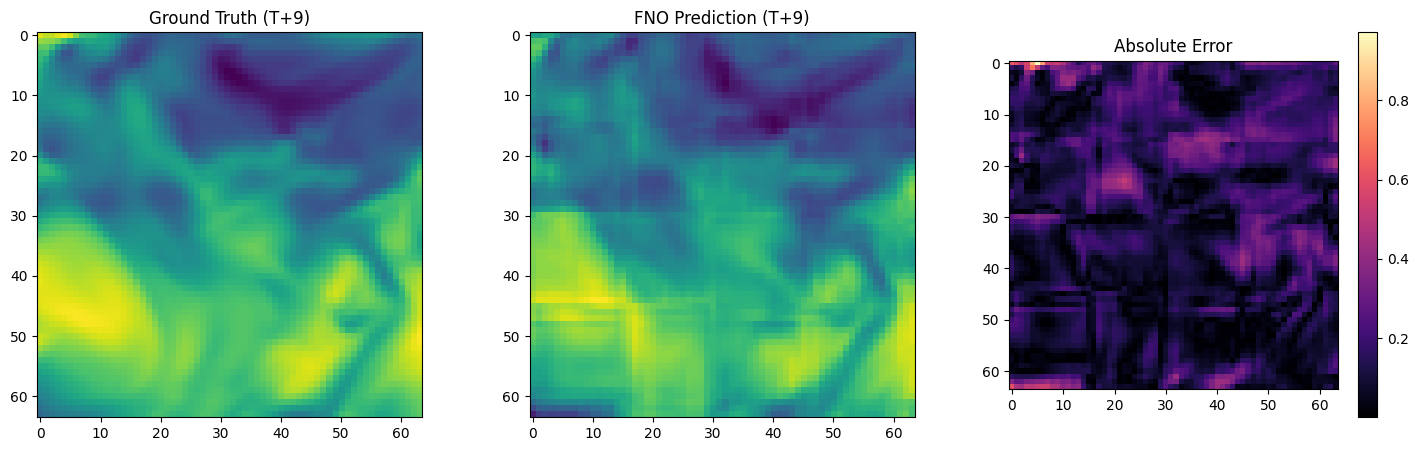

In [12]:
import torch

from pipeline import (
    load_checkpoint,
    setup_grids,
    validate_autoregressive,
)


VAL_TIMESTEPS = 10
DATASET = "jhtdb"
JHTDB_PATH = "../JHTDB/data/jhtdb_test/small_planes.h5"
VAL_Z = [288]

CHECKPOINT_PATH = "./models/fno_e200_k3_n16_top25.pt"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


checkpoint, trained_models = load_checkpoint(
    CHECKPOINT_PATH,
    device,
)

print(f"Device: {device}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Model Type: {checkpoint['model_type'].upper()}")
print(f"Epochs: {checkpoint['epochs']}")
print(f"Number of clusters: {checkpoint['k_cluster']}")
print(f"Subdomain size: {checkpoint['n']}")
print(f"Spectral bins: {checkpoint['top_p']}")


grid_data = setup_grids(
    checkpoint["model_type"],
    checkpoint["n"],
    device,
)


validate_autoregressive(
    trained_models=trained_models,
    centroids=checkpoint["centroids"],
    grid_data=grid_data,
    model_type=checkpoint["model_type"],
    n=checkpoint["n"],
    top_p=checkpoint["top_p"],
    val_timesteps=VAL_TIMESTEPS,
    device=device,
    dataset=DATASET,
    data_path=JHTDB_PATH,
    val_z=VAL_Z,
)
